In [ ]:
import time
import requests
from bs4 import BeautifulSoup as bsSoup
import warnings
import pandas as pd
import os
from collections import OrderedDict

**a.** Design and implement a solution to crawl the publication title, publication venue, publication year, author list and of every unique publication record on the target website. **[15%]**

In [ ]:
publicationsIndex = "https://sitescrape.awh.durham.ac.uk/comp42315/publicationfull_year_characteranimation.htm"

# function that scrapes the links of all the sites where unique publications can be
def getLinks (url: str) -> list :
    sitePrefix = "https://sitescrape.awh.durham.ac.uk/comp42315/"

    if (not isinstance(url, str)) :
        print("The URL needs to be a string!")
        return []

    # wait a little so we don't overload the server
    time.sleep(2)
    publicationsIndex = requests.get(url, verify = False)

    if (publicationsIndex.status_code != 200) :
        print (f"Error; status code returned: {publicationsIndex.status_code}")
        return []

    publicationsIndexSoup = bsSoup(publicationsIndex.content, "html.parser").body

    if (publicationsIndexSoup == None) :
        print ("Nothin to parse on the site")
        return []

    publicationLinksA = publicationsIndexSoup.find("p", class_ = "TextOption").find_all("a")

    if (publicationLinksA == None) :
        print ("No links found")
        return []
    
    links = [sitePrefix + n.get("href") for n in publicationLinksA]

    if (links[0] == None) :
        print("No links found")
        return []

    return links

In [ ]:
categoriesUrls = [publicationsIndex] + getLinks(publicationsIndex)

# this funcion scrapes publication title, publication type (only bit that can't be acquired on the publication's page) and the link of the webpage - this link is needed to acquire the precise impact score and citation count - it also has the remaining required information: year, venue, list of authors; it returns a dictionary in a format:
# key: publication type -> value: [title, page link]
def scrapePublicationWebpageLinks (urls: list, replace : str) -> dict :
    scrapedData = {}
    seenTitles = set()   # ensure we only get each title once
    sitePrefix = "https://sitescrape.awh.durham.ac.uk/comp42315/"

    for url in urls :
        uniqueValuesOnPage = []
        time.sleep(0)
        url = url.replace("year", replace)

        page = requests.get(url, verify = False)

        if (page.status_code != 200) :
            print(f"Failed for link {url}, status code: {page.status_code}, continuing execution for the remaining links")
            continue

        pageSoup = bsSoup(page.content, "html.parser").body

        if (pageSoup == None) :
            print (f"Found nothing to parse on site {url}, continuing execution for the remaining links")
            continue

        pageSoupDiv = pageSoup.find("div", id = "divBackground")

        if (pageSoupDiv == None) :
            print (f"Couldn't find {replace} on the page {url}, continuing execution for the remaining links")
            continue

        pageSoupP = pageSoupDiv.find_all("p", class_ = "TextOption")

        if (pageSoupP == None) :
            print (f"Couldn't find {replace} on the page {url}, continuing execution for the remaining links")
            continue

        paragraphWithInfo = pageSoupP [2]

        valueTags = paragraphWithInfo.find_all("a")

        uniqueValuesOnPage = [n.text for n in valueTags]

        if (len(uniqueValuesOnPage) == 0) :
            print (f"Couldn't find {replace} on the page {url}, continuing execution for the remaining links")
            continue

        for value in uniqueValuesOnPage :
            currentH2 = pageSoup.find("h2", id = value)

            if (currentH2 == None) :
                continue

            if (value not in scrapedData) :
                scrapedData [value] = []

            div = currentH2.findNext()

            publicationsWithThisInfo = div.find_all("div", class_ = "w3-cell-row")

            if (publicationsWithThisInfo == None) :
                continue

            for publication in publicationsWithThisInfo :
                publicationText = publication.find("div", class_ = "w3-container w3-cell w3-mobile w3-cell-middle")

                title = publicationText.text.split("by")[0].strip()

                if (title in seenTitles) :
                    continue

                seenTitles.add(title)

                span = publicationText.find("span")

                publicationLink = span.find("a").get("href")

                listToAdd = [title, sitePrefix + publicationLink]
                scrapedData[value].append(listToAdd)

    return scrapedData

initialScrape = scrapePublicationWebpageLinks(categoriesUrls, "type")

# extract the urls of the publications' sites to a list
publicationUrls : str = []

for k in initialScrape :
    for n in initialScrape[k] :
        publicationUrls.append(n[1])

# this funciton uses the links scraped by the previous funcion and it scrapes all of the remainig information that is needed: author list, year, venue 
def scrapeAdditionalInformation (urls: list) -> dict :
    addtionalInfo = {}

    # find the title, find number of citations and the impact score
    for url in urls :
        time.sleep(0)
        
        infoPage = requests.get(url, verify = False)

        if (infoPage.status_code != 200) :
            print(f"Failed for link {url}, status code: {infoPage.status_code}, continuing execution for the remaining links")
            continue

        infoPageSoup = bsSoup(infoPage.content, "html.parser").body

        if (infoPageSoup == None) :
            print (f"Found nothing to parse on site {url}, continuing execution for the remaining links")
            continue

        infoPageSoupDiv = infoPageSoup.find_all("div", style = "margin-left: var(--size-marginleft)")[1]

        if (infoPageSoupDiv == None) :
            print (f"Found no divs maching the criteria on site {url}, continuing execution for the remaining links")
            continue 

        infoPageSoupP = infoPageSoupDiv.find("p")

        if (infoPageSoupP == None) :
            print (f"Found no paragraphs maching the criteria on site {url}, continuing execution for the remaining links")
            continue 
        
        title = infoPageSoupP.text.split("by")[0].strip()

        # so that is going to have the number of citations and impact score IF the publication had any
        infoPageSoupDiv2 = infoPageSoupDiv.find_all("div")[2].text
        # then add to dictionary
        addtionalInfo[title] = infoPageSoupP.text + infoPageSoupDiv2

    return addtionalInfo
 

supportingInfo = scrapeAdditionalInformation(publicationUrls)

In [ ]:
# those 2 funcitons will combine the results from the two dictionaries acquired in the previous step
def dictConverter (dataDict : dict) -> dict :
    convertedDict = {}

    for k in dataDict :
        for n in dataDict[k] :
            convertedDict[n[0]] = k

    return convertedDict

def dictCombine (dict1 : dict, dict2 : dict) -> dict :
    combined = {}

    if (len(dict1) != len(dict2)) :
        return {}

    for k in dict1 :
        if (k not in dict1 or k not in dict2) :
            continue

        combined[k] = [dict1[k], dict2[k]]

    return combined

typeDictClean = dictConverter(initialScrape)
rawDataFinal = dictCombine(typeDictClean, supportingInfo)   # this is the final scraped data that I will be working with
#print (rawDataFinal)

**b.**	This information should then be stored and displayed in an appropriate format. Displayed to the user should be: publication title, publication venue, year and author list of every unique publication record on the target website. **[10%]** 

In [ ]:
# this part of the code cleans up the data and stores it into a dictionary and a pandas dataframe

publications = {}   # dictionary for the cleaned up data
authorsListConcat : str = []    # dataframe needs authors for each publication as a single string rather than a list of strings
publicationsData : pd.DataFrame

# 
for k in rawDataFinal :
    title : str = k # title is jus the key
    allData : str = rawDataFinal[k][0] + "REST " + rawDataFinal[k][1]
    remainder = ""

    initialClean = allData.translate({ord(i): None for i in '\t\r\n'})  # remove any tabs, new lines etc.
    splitAt = initialClean.find("REST")

    typeOfPublication = initialClean[:splitAt]
    remainder = initialClean[splitAt + 4:]

    # remove title
    splitAt = initialClean.find("by")
    remainder = initialClean[splitAt + 3:]

    # find authors
    splitAt = remainder.find(" in ")
    authors = remainder[:splitAt]

    # extract year of the publication
    year = int(remainder[splitAt + 4:splitAt + 8])
    remainder = remainder[splitAt + 8:]

    authorsListConcat.append(authors)

    # splitting authors into a list of names
    if (len(authors) != 0) :
        authorList1 = authors.split(",")
        authorList2 = authorList1[-1].split("and")
        authorList1Strip = [n.strip() for n in authorList1]
        authorList2Strip = [n.strip() for n in authorList2]
        authorList = authorList1Strip[:-1] + authorList2Strip
    else :
        authorList = []
    
    noOfAuthors = len(authorList)

    # split into publication venue, citations and imact factor if it has one
    splitAt = remainder.find("Citation")
    publicationVenue = remainder[:splitAt]
    remainder = remainder[splitAt + len("Citation: "):]

    split = remainder.split("##")
    citations = int(split[0])

    remainder = split[1]

    impactFactorRaw = remainder.split(": ")
    impactFactor = 0

    # by default impact factor is 0, if a publication has one then change the variable to it
    if (len(impactFactorRaw) > 1) :
        impactFactor = float(impactFactorRaw[1][:-1])

    # add to dictionary
    publications[title] = [authorList, year, publicationVenue, typeOfPublication, citations, impactFactor, noOfAuthors]

#print (publications)
    

In [ ]:
_data = {"title" : [k for k in publications], 
         "authors" : [n for n in authorsListConcat], 
         "year" : [publications[k][1] for k in publications], 
         "publication venue" : [publications[k][2] for k in publications],
         "type" : [publications[k][3] for k in publications],
         "number of citations" : [publications[k][4] for k in publications],
         "impact" : [publications[k][5] for k in publications],
         "number of authors" : [publications[k][6] for k in publications]
         }
         
publicationsData = pd.DataFrame(data = _data)

#publicationsData.head()

In [ ]:
# following 3 functions allow for displaying of data: printing formatted data to the console, exporting to .csv and .txt files
def printScrapedDataToConsole (_dict : dict) -> None :
    s = 1
    for k in _dict :
        print ("---")
        print (s)
        print (f"Title: {k}\n")
        print("Authors: ")

        count = 0
        for n in _dict[k][0] :
            if (len(_dict[k][0]) == 1 and n == "") :
                print("No authors found")
            elif (len(_dict[k][0]) == 1) :
                print(n)
            elif (count == len(_dict[k][0]) - 1) :
                print("and " + n + ".") 
            else :
                print(n + ", ")
            count += 1
            
        print (f"\nYear published: {_dict[k][1]}")
        print (f"Publication venue: {_dict[k][2]}")
        print (f"Type: {_dict[k][3]}")
        print (f"Number of citations: {_dict[k][4]}")
        print (f"Impact Factor: {_dict[k][5]}")

        print (f"Number of authors: {_dict[k][6]}")
        print ("---\n")

        s += 1

#printScrapedDataToConsole(publications)

In [ ]:
def exportToCsv (fileName : str, _data : pd.DataFrame) -> None :
    if (_data.empty) :
        print ("Provide correct Data Frame")
        return

    # if file name is not a string, cast it to string
    if (not isinstance(fileName, str)) :
        fileName = str(fileName)

    # if file exists, don't overwrite it  
    if (os.path.exists(f"./{fileName}.csv")) :
        warnings.warn ("This file already exists")
        return
    
    # if filename does not end in .csv, append .csv
    if (fileName[-4:] != ".csv") :
        fileName = fileName + ".csv"
    
    _data.to_csv(f"{fileName}", index = False)

def exportToTxt (fileName : str, _data : dict) -> None :
    if (not isinstance(fileName, str)) :
        fileName = str(fileName)

    if (os.path.exists(f"./{fileName}.txt")) :
        warnings.warn ("This file already exists")
        return

    if (fileName[-4:] != ".txt") :
        fileName = fileName + ".txt"

    with open (fileName, "w") as f :
        for k in _data :
            f.write(f"{k}\n")

            f.write("by")
            s = 0
            for n in _data[k][0] :
                if (s == len(_data) - 1) :
                    f.write(n)
                else :
                    f.write(n + ", ")
                s += 1

            f.write(f". {_data[k][1]}, {_data[k][2]}, {_data[k][3]}, number of citations: {_data[k][4]}, impact factor: {_data[k][5]}\n")
            f.write("\n")

#exportToCsv("myCsvFile", publicationsData)
#exportToTxt("myTxtFile", publications)

**c.**	The records should be manipulatable: at minimum you should be able to display sorted information according to descending year values, descending number of author values, the titles from A to Z, and finally by the impact of the papers.  **[10%]** 

Note, this does not require user interaction, this can and should be completed via pre defined functions. 

In [ ]:
# this function can sort by any column of the dataframe, in ascending or descending order, it can also output to .csv as Jupyter notebook won't display entire dataframe
def sortDataFrame (_data : pd.DataFrame, sortBy : str, asc : bool = True, toCsv : bool = False) -> None :
    if (_data.empty) :
        print ("Provide correct Data Frame")
        return
    
    if (sortBy not in _data) :
        print(f"Column {sortBy} not found dataframe")
        return

    df = _data.sort_values(by = [sortBy], ascending = asc)
    display(df)

    if (toCsv) :
        exportToCsv(f"data sorted by {sortBy}", _data)

# this funtion sorts the publications dictionary, prints to console and can write to a .txt file
# sortBy: title, authors, venue, impact, citations, year, type; desc = True for descending order
def displaySortedPublications (sortBy : str, desc : bool = False, toTxt : bool = False) -> None :
    # so, sort it and display to console and if needed output as txt
    if (sortBy == "title") :
        sortedPublications = dict(sorted(publications.items(), reverse = desc))

    if (sortBy == "authors") :
        sortedPublications = OrderedDict(sorted(publications.items(), key = lambda item : item[1][6], reverse = desc))

    if (sortBy == "citations") :
        sortedPublications = OrderedDict(sorted(publications.items(), key = lambda item : item[1][4]))

    if (sortBy == "impact") :
        sortedPublications = OrderedDict(sorted(publications.items(), key = lambda item : item[1][5]))

    if (sortBy == "year") :
        sortedPublications = OrderedDict(sorted(publications.items(), key = lambda item : item[1][1]))

    if (sortBy == "venue") :
        sortedPublications = OrderedDict(sorted(publications.items(), key = lambda item : item[1][2]))

    if (sortBy == "type") :
        sortedPublications = OrderedDict(sorted(publications.items(), key = lambda item : item[1][3]))

    print(f"Records are sorted by {sortBy}\n")

    printScrapedDataToConsole(sortedPublications)

    if (toTxt) :
        exportToTxt(f"data sorted by {sortBy}", sortedPublications)
    

#sortDataFrame(publicationsData, "number of citations")
#sortDataFrame(publicationsData, "title")
#sortDataFrame(publicationsData, "publication venue", False)
#sortDataFrame(publicationsData, "type", toCsv = True)
#sortDataFrame(publicationsData, "impact", False)
#sortDataFrame(publicationsData, "number of authors")

#displaySortedPublications("title")
#displaySortedPublications("year")
#displaySortedPublications("authors", True)
#displaySortedPublications("venue")
#displaySortedPublications("impact", True, True)
#displaySortedPublications("type")
#displaySortedPublications("citations", toTxt=True)

**d.** Good programming practice: marks will be given for good Python programming practice **[10%]**

- Defensive programming: checking the response codes after an https request, checking that the links are in correct format, checking for None before parsing or after searching via beautiful soup
- Making the function scraping wait a few seconds between each request so the server is not overloeaded
- Using descriptive and unique variable names
- Where adequate adding comments to explain the code - at the start of the funciton or where the code is complicated
- Encapsulating code into functions for reusablity and to limit the number of global variables
- Adding type hints to the function params and outputs to improve usablility 
- Using list comprehensions and built-in methods to achieve Pythonic code

**e.** Explain your design and highlight any features in this question’s report part of your Jupyter Notebook in no more than 300 words. Reflect upon the importance of well structured HTML. **[5%]**

My design firstly scrapes the links to pages where all publications can be found, then constructs a dictionary of unique publications (keys) to their page links, and publication types (values). Those links will be used to scrape all remaining required data and store it in a second dictionary. Then both dictionaries are combined, and the data is ready for munginig. The clean data is stored as a dictionary of publication titles (keys) and [authorList, year, publicationVenue, typeOfPublication, citations, impactFactor, noOfAuthors] as values. An algorithm is used to clean up the strings that hold all the information by searching for a phrase and gradually splitting it into variables, and adding them to the dictionary. A Pandas dataframe is also constructed. Data can be displayed in a few ways: displaying the Pandas dataframe, printing formatted data to the console or exporting to a .csv or .txt file. The records can be sorted by any of the variables and in ascending or descending order. The user can choose to sort and display either the dataframe or the dictionary. It is also possible to export the results to a .csv or .txt file.

In my opinion, although this webpage's HTML was structured weirdly, with non-descriptive classes/ ids, it was consistent in its design. It is important that a website's HTML is well structured, most importantly for accessibility reasons, so that, for e.g. screen readers can perform well. When it comes to scraping and munging, it is ideal and makes the developer’s life easier, but we should not expect that all sites will be organised. I just believe that such practices are in an ethical grey area, so maybe it is good when it becomes more of a challenge trying to navigate the DOM.

Question 2

In [347]:
import random as rd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.feature_selection import r_regression, SelectKBest, SequentialFeatureSelector
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

droneData = pd.read_csv("drone.csv")
display(droneData)

,timestamp,voltage_v,voltage_filtered_v,current_a,current_filtered_a,discharged_mah,remaining,scale,load,ram_usage,warning
0,32308201184,23.821001,23.832287,0.1612,0.231098,2478.49240,0.868972,1.018116,0.636926,0.789424,0
1,32308703643,23.681600,23.805693,0.4464,0.261076,2478.52860,0.872252,1.017655,0.741170,0.850598,0
2,32309206808,23.583200,23.732930,0.8680,0.530416,2478.62600,0.857639,1.019714,0.741170,0.850598,0
3,32309709975,23.534000,23.650160,0.9176,0.848289,2478.78250,0.837432,1.022576,0.719303,0.850598,0
4,32310213186,23.566800,23.614992,0.9176,0.879427,2478.90770,0.829972,1.023636,0.719303,0.850598,0
...,...,...,...,...,...,...,...,...,...,...,...
5720,217939580,23.509400,21.047533,0.8804,4.778114,893.38200,0.189368,1.123704,0.711884,0.857463,3
5721,218430765,23.378200,21.816160,1.1904,2.821448,893.55980,0.377933,1.092273,0.712891,0.857463,3
5722,218934951,23.378200,22.354784,1.1656,1.881340,893.72450,0.511203,1.071099,0.712891,0.857463,3
5723,219437924,23.739000,22.807766,0.2976,1.135152,893.81665,0.616517,1.054939,0.709789,0.857735,3


**a.** Selection of training set. Write code splitting the given dataset into the training and testing
sets. The output of the code should be a dataset consisting of the rows of drone.csv that
have been chosen. In the text part of your submission, please justify your choice. **[5%]**

In [348]:
def takeBootstrapSample (inBagProportion: float, df: pd.DataFrame) -> tuple :
    rowIndicies = []
    for i in range(1,droneData.shape[0] + 1) :
        rowIndicies.append(i)

    trainingSubsetRows = rd.sample(rowIndicies, round(len(rowIndicies) * inBagProportion))
    # converting to sets
    allRowsS = set (rowIndicies)
    trainingRowsS = set (trainingSubsetRows)
    validationSubsetRowsS = allRowsS - trainingRowsS
    # now get the actual rows from the dataframe
    trainingRowsBool = []
    validationRowsBool = []
    for i in rowIndicies :
        if i in trainingRowsS :
            trainingRowsBool.append(True)
        else :
            trainingRowsBool.append(False)

        if i in validationSubsetRowsS :
            validationRowsBool.append(True)
        else :
            validationRowsBool.append(False)

    trainingData = df.iloc[trainingRowsBool]
    validationData = df.iloc[validationRowsBool]

    return (trainingData, validationData)

bootstrapSample = takeBootstrapSample(0.75, droneData)

**b.** Feature selection (applied to the training set only). In this task you are requested to write
code for testing of two feature selection approaches of your choice. The output of
implementation of each approach should be the dataset with three features obtained from
the output of part **a.** by removal of those columns that have not been selected as features. **[25%]**

In [350]:
trainingDataset = bootstrapSample[0]
testingDataset = bootstrapSample[1]

# split the dataframe into the predictors and response
# for training
allPredictors = trainingDataset.loc[:, trainingDataset.columns != "warning"].dropna()
response = trainingDataset["warning"].drop(33)


# convert to numpy array
allPredictorsNp = allPredictors.to_numpy()
responseNp = response.to_numpy()

# calculate the Pearson correlation coefficients via the r-regression
scores = r_regression(allPredictorsNp, responseNp)

# select k best approach

# apparently that works with a data frame directly
selector = SelectKBest(r_regression, k = 3)
selectKBestRawOut = selector.fit_transform(allPredictors, response)

colIds = selector.get_support(indices = True)

skbOutDf = trainingDataset.iloc[:, colIds]
#print(skbOutDf.columns)

# using sequential feature selection
knn = KNeighborsRegressor(3)
sequentialFeatureSelectRawOut = SequentialFeatureSelector(knn, n_features_to_select = 3).fit(allPredictors, response)
cols = sequentialFeatureSelectRawOut.get_support(indices = True)
sfsOutDf = trainingDataset.iloc[:, cols]
#print (sfsOutDf.columns)

# now the testing variables
testingForSKB = testingDataset.loc[:, ['current_a', 'current_filtered_a', 'scale']]
testingForSFS = testingDataset.loc[: ,['current_a', 'voltage_filtered_v', 'remaining']]
responseTesting = testingDataset["warning"]

**c.** Data binning (applied to the training set only) In this task you are requested to carry out data binning for the features of each data set obtained at the output of the previous part.
<ul>
<li>i. In particular, the values of each feature should be divided into 5 intervals with the smallest and largest values being the start and the end of the interval being partitioned. </li>
<li> ii. After that each value is to be replaced with the interval it belongs. </li>
<li> iii. Please implement two versions of binning for each data frame. </li>
<li> iv. In the first part just apply an ordinary binning. In the second part, the binning should be preceded by removal of outliers. The removal of outliers should be based on the interquartile range (IQR) method. Recall that, according to this method, a value is an outlier is it is smaller than the first quartile by more than 1.5IQR or greater than the third quartile by more than 1.5IQR. </li>
<li> v. Thus, the output of this step will consist of four datasets obtained by applying two ways of binning for each dataset obtained as the output of the previous step. </li>
<li> vi. In the text part (part f) of this task, please briefly discuss positive and negative effects of binning and removal of outliers in the context of ML. </li> 
</ul>  

**[5%]**

In [352]:
def diagnosticPlots () :
    plt.scatter(skbOutDf["current_a"], skbOutDf["current_filtered_a"])
    plt.title("scatterplot of current_filtered_a vs current_a")
    plt.show()
    print ("Person corr matrix for current_a and current_filtered_a - very strong positive correlation")
    print (np.corrcoef(skbOutDf["current_a"], skbOutDf["current_filtered_a"]))

    plt.scatter(sfsOutDf["voltage_filtered_v"], sfsOutDf["current_a"])
    plt.title("scatterplot of voltage_filtered_v vs current_a")
    plt.show()
    print (np.corrcoef(sfsOutDf["voltage_filtered_v"], sfsOutDf["current_a"]))

    fig, axs = plt.subplots(2)
    fig.suptitle("current_a")
    axs[0].scatter(skbOutDf.index, skbOutDf["current_a"], alpha = 0.4, s = 9)
    axs[1].hist(skbOutDf["current_a"], bins = 15)

    fig1, axs = plt.subplots(2)
    fig1.suptitle("current_filtered_a")
    axs[0].scatter(skbOutDf.index, skbOutDf["current_filtered_a"], alpha = 0.4, s = 9)
    axs[1].hist(skbOutDf["current_filtered_a"], bins = 15)

    fig2, axs = plt.subplots(2)
    fig2.suptitle("scale")
    axs[0].scatter(skbOutDf.index, skbOutDf["scale"], alpha = 0.4, s = 9)
    axs[1].hist(skbOutDf["scale"], bins = 6)

    fig3, axs = plt.subplots(2)
    fig3.suptitle("remaining")
    axs[0].scatter(sfsOutDf.index, sfsOutDf["remaining"], alpha = 0.4, s = 9)
    axs[1].hist(sfsOutDf["remaining"], bins = 6)

    fig4, axs = plt.subplots(2)
    fig4.suptitle("voltage_filtered_v")
    axs[0].scatter(sfsOutDf.index, sfsOutDf["voltage_filtered_v"], alpha = 0.4, s = 9)
    axs[1].hist(sfsOutDf["voltage_filtered_v"], bins = 12)


#diagnosticPlots()
# oh god almighty


# print (skbOutDf.columns)
# print (skbOutDf.shape)
# print (skbOutDf)

In [353]:
# binning with cut()
# first the training data
currentACut = pd.cut(skbOutDf["current_a"], 5, labels = False)
currentFilteredACut = pd.cut(skbOutDf["current_filtered_a"], 5, labels = False)
scaleCut = pd.cut(skbOutDf["scale"], 5, labels = False)
remainingCut = pd.cut(sfsOutDf["remaining"], 5, labels = False)
voltageCut = pd.cut(sfsOutDf["voltage_filtered_v"], 5, labels = False)

skbOutBinnedDict = {"current_a" : currentACut, "current_filtered_a" : currentFilteredACut, "scale" : scaleCut}

sfsOutBinnedDict = {"voltage_filtered_v" : voltageCut, "current_a" : currentACut, "remaining" : remainingCut}

skbOutBinned = pd.DataFrame(data = skbOutBinnedDict)
sfsOutBinned = pd.DataFrame(data = sfsOutBinnedDict)

# now the testing data
currentACutTest = pd.cut(testingForSKB["current_a"], 5, labels = False)
currentFilteredACutTest = pd.cut(testingForSKB["current_filtered_a"], 5, labels = False)
scaleCutTest = pd.cut(testingForSKB["scale"], 5, labels = False)
remainingCutTest = pd.cut(testingForSFS["remaining"], 5, labels = False)
voltageCutTest = pd.cut(testingForSFS["voltage_filtered_v"], 5, labels = False)

skbOutBinnedTDict = {"current_a" : currentACutTest, "current_filtered_a" : currentFilteredACutTest, "scale" : scaleCutTest}

sfsOutBinnedTDict = {"voltage_filtered_v" : voltageCutTest, "current_a" : currentACutTest, "remaining" : remainingCutTest}

skbOutBinnedTest = pd.DataFrame(data = skbOutBinnedTDict)
sfsOutBinnedTest = pd.DataFrame(data = sfsOutBinnedTDict)

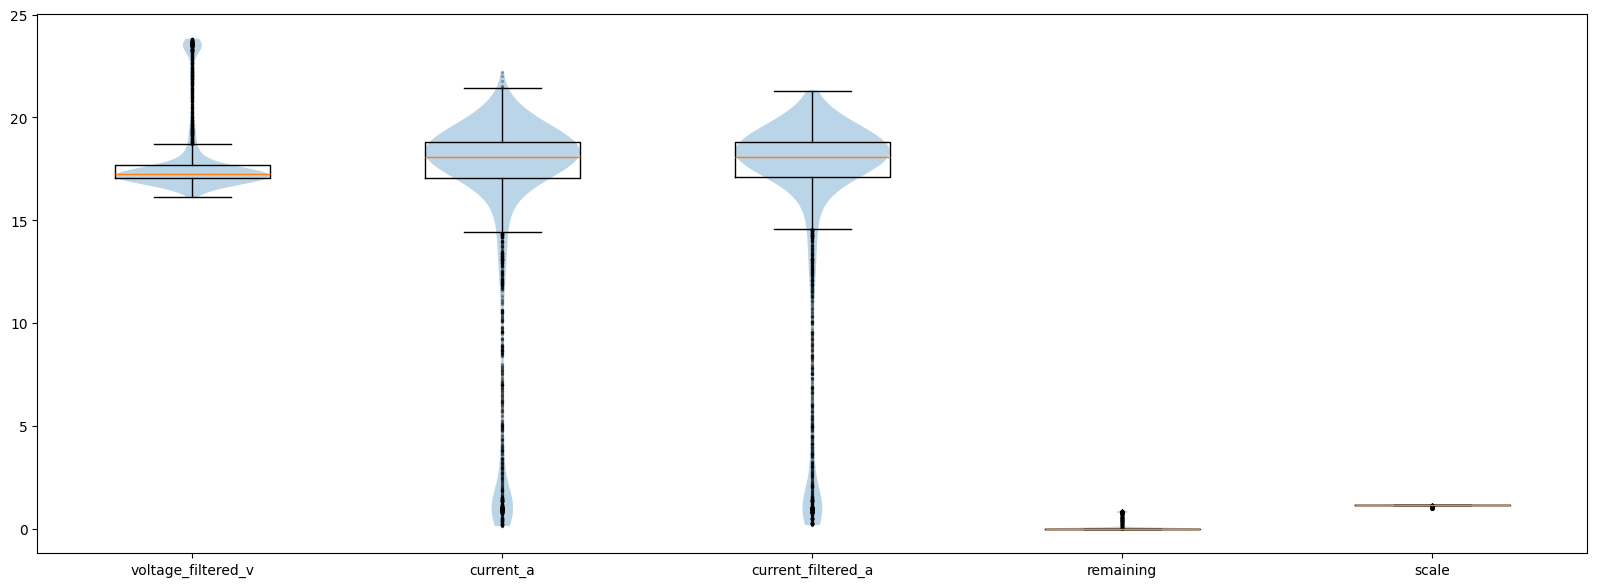

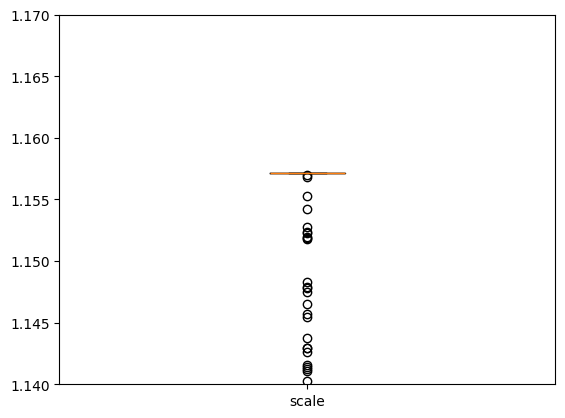

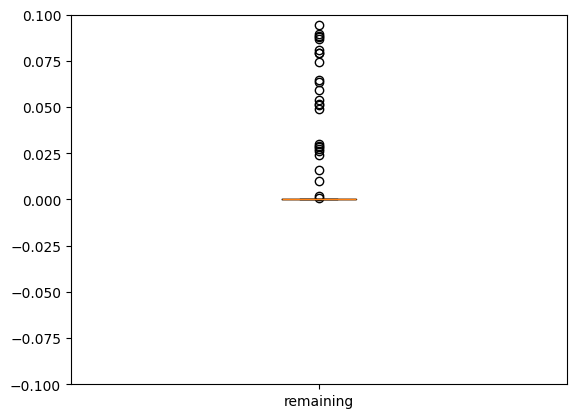

In [354]:
# binning with qcut()
# remove outliers first
boxPlotLabels = [droneData.columns[2], droneData.columns[3], droneData.columns[4], droneData.columns[6], droneData.columns[7]]

fig = plt.figure(figsize = (20, 7))
ax = fig.add_subplot(111)
boxP = ax.boxplot(droneData.iloc[:,[2, 3, 4, 6, 7]], tick_labels=boxPlotLabels)
for flier in boxP["fliers"] :
    flier.set(
        marker = "o",
        markersize = 1.4,
        alpha = 0.3
    )
ax.violinplot(droneData.iloc[:,[2, 3, 4, 6, 7]], showextrema=False)
plt.show()

plt.boxplot(skbOutDf["scale"], tick_labels = ["scale"])
plt.ylim(1.14, 1.17)
plt.show()

plt.boxplot(sfsOutDf["remaining"], tick_labels = ["remaining"])
plt.ylim(-0.1, 0.1)
plt.show()

# display(skbOutDf.quantile([0.25, 0.5, 0.75]))
# display(sfsOutDf.quantile([0.25, 0.5, 0.75]))


In [355]:
# 'scale' and 'remaining' produce no IQR so I will not be dropping any of the values
# anything bigger than Q3 or lower than Q1 get rid of
currentAQ1 = skbOutDf["current_a"].quantile([0.25]).iloc[0]
currentAQ3 = skbOutDf["current_a"].quantile([0.75]).iloc[0]

currentFilteredAQ1 = skbOutDf["current_filtered_a"].quantile([0.25]).iloc[0]
currentFilteredAQ3 = skbOutDf["current_filtered_a"].quantile([0.75]).iloc[0]

voltageFilteredVQ1 = sfsOutDf["voltage_filtered_v"].quantile([0.25]).iloc[0]
voltageFilteredVQ3 = sfsOutDf["voltage_filtered_v"].quantile([0.75]).iloc[0]

currentNoOutliers = skbOutDf.loc[(skbOutDf["current_a"] <= currentAQ3) & (skbOutDf["current_a"] >= currentAQ1), "current_a"]
currentFilteredNoOutliers = skbOutDf.loc[(skbOutDf["current_filtered_a"] <= currentFilteredAQ3) & (skbOutDf["current_filtered_a"] >= currentFilteredAQ1), "current_filtered_a"]
voltageFilteredNoOutliers = sfsOutDf.loc[(sfsOutDf["voltage_filtered_v"] <= voltageFilteredVQ3) & (sfsOutDf["voltage_filtered_v"] >= voltageFilteredVQ1), "voltage_filtered_v"]

skbNoOutliers = {"current_a" : currentNoOutliers, "current_filtered_a" : currentFilteredNoOutliers, "scale" : skbOutDf["scale"]}
sfsNoOutliers = {"voltage_filtered_v" : voltageFilteredNoOutliers, "current_a" : currentNoOutliers, "remaining" : sfsOutDf["remaining"]}

skbNoOutDf = pd.DataFrame(data = skbNoOutliers)
sfsNoOutDf = pd.DataFrame(data = sfsNoOutliers)

currentAQcut = pd.qcut(skbNoOutDf["current_a"], 5, labels = False)
currentFilteredAQCut = pd.qcut(skbNoOutDf["current_filtered_a"], 5, labels = False)
scaleQCut = pd.qcut(skbNoOutDf["scale"], 5, duplicates = "drop", labels = False)
remainingQCut = pd.qcut(sfsNoOutDf["remaining"], 5, duplicates = "drop", labels = False)
voltageQCut = pd.qcut(sfsNoOutDf["voltage_filtered_v"], 5, labels = False)

skbNoOutDictAlmost = {"current_a" : currentAQcut, "current_filtered_a" : currentFilteredAQCut, "scale" : scaleQCut}
sfsNoOutDictAlmost = {"current_a" : currentAQcut, "voltage_filtered_v" : voltageQCut, "remaining" : remainingQCut}

skbOutBinnedNoOut = pd.DataFrame(data = skbNoOutDictAlmost)
sfsOutBinnedNoOut = pd.DataFrame(data = sfsNoOutDictAlmost)

In [ ]:
# # standardize
# scale1 = StandardScaler().fit_transform(skbOutDf)
# scale2 = StandardScaler().fit_transform(sfsOutDf)
# skbOutScaled = pd.DataFrame(scale1, columns=skbOutDf.columns)
# sfsOutScaled = pd.DataFrame(scale2, columns = sfsOutDf.columns)

# display(skbOutScaled.quantile([0.25, 0.5, 0.75]))
# display(sfsOutScaled.quantile([0.25, 0.5, 0.75]))

# # ok so I am going to use standardised data from now on for binning, so need to do the same shit again

# # let's see if I can bin with qcut once outliers have been removed
# currentStandardQ1 = skbOutScaled["current_a"].quantile([0.25]).iloc[0]
# currentStandardQ3 = skbOutScaled["current_a"].quantile([0.75]).iloc[0]
# # anything bigger than Q3 or lower than Q1 get rid of

# currentFilteredStandardQ1 = skbOutScaled["current_filtered_a"].quantile([0.25]).iloc[0]
# currentFilteredStandardQ3 = skbOutScaled["current_filtered_a"].quantile([0.75]).iloc[0]

# scaleStandardQ1 = skbOutScaled["scale"].quantile([0.25]).iloc[0]
# scaleStandardQ3 = skbOutScaled["scale"].quantile([0.75]).iloc[0]

# voltageFilteredStandardQ1 = sfsOutScaled["voltage_filtered_v"].quantile([0.25]).iloc[0]
# voltageFilteredStandardQ3 = sfsOutScaled["voltage_filtered_v"].quantile([0.75]).iloc[0]

# remainingStandardQ1 = sfsOutScaled["remaining"].quantile([0.25]).iloc[0]
# remainingStandardQ3 = sfsOutScaled["remaining"].quantile([0.75]).iloc[0]

# print(currentStandardQ1, currentStandardQ3)
# print(currentFilteredStandardQ1, currentFilteredStandardQ3)
# print(voltageFilteredStandardQ1, voltageFilteredStandardQ3)
# print(scaleStandardQ1, scaleStandardQ3)
# print(remainingStandardQ1, remainingStandardQ3)

# didn't do much, I think I just need to get rid of remaining and scale those are just bad


,current_a,current_filtered_a,scale
0.25,0.165550,0.185907,0.353289
0.50,0.363669,0.372456,0.353289
0.75,0.504604,0.503971,0.353289


,voltage_filtered_v,current_a,remaining
0.25,-0.503850,0.165550,-0.351336
0.50,-0.392065,0.363669,-0.351336
0.75,-0.156540,0.504604,-0.351336


0.16555021657518573 0.5046039945107167
0.1859073639842047 0.5039705166448796
-0.5038497934833686 -0.15654000392359801
0.3532887541153216 0.3532887541153216
-0.3513357355685346 -0.3513357355685346


**d** For each of the four data sets obtained as the output of the previous step, run the decision
tree classifier with 'warning' being the target variable. Thus, the output of the programming
part are four decision trees. In the discussion part of this task please discuss the sizes of the
obtained decision trees. Conclude whether removal of outliers has any effect pm the size of
the decision tree and which of the feature selection algorithms resulted in a more compact
decision tree. **[7.5%]**

In [356]:
dtc0 = DecisionTreeClassifier(random_state = 42)
dtc1 = DecisionTreeClassifier(random_state = 42)
dtc2 = DecisionTreeClassifier(random_state = 42)
dtc3 = DecisionTreeClassifier(random_state = 42)

# trees trained on the data without removal of outliers
treeSKB = dtc0.fit(skbOutBinned.drop(42), response)
tSkbDepth = treeSKB.get_depth()
tSkbNLeaves = treeSKB.get_n_leaves()
print (f"""Decision tree trained on the variables obtained from the Select K Best approach, 
and binned without removal of outliers has depth {tSkbDepth} and {tSkbNLeaves} leaves""")

treeSFS = dtc1.fit(sfsOutBinned.drop(42), response)
tSfsDepth = treeSFS.get_depth()
tSfsNLeaves = treeSFS.get_n_leaves()
print (f"""\nDecision tree trained on the variables obtained from the Sequential Feature Select,
and binned without removal of outliers has depth {tSfsDepth} and {tSfsNLeaves} leaves""")

# with outliers removed
treeSKBOutRem = dtc2.fit(skbOutBinnedNoOut.drop(42), response)
tSkbNoOUtDepth = treeSKBOutRem.get_depth()
tSkbNoOutNLeaves = treeSKBOutRem.get_n_leaves()
print (f"""\nDecision tree trained on the variables obtained from the Select K Best approach, 
and binned without removal of outliers has depth {tSkbNoOUtDepth} and {tSkbNoOutNLeaves} leaves""")

treeSFSOutRem = dtc3.fit(sfsOutBinnedNoOut.drop(42), response)
tSfsNoOUtDepth = treeSFSOutRem.get_depth()
tSfsNoOutNLeaves = treeSFSOutRem.get_n_leaves()
print (f"""\nDecision tree trained on the variables obtained from the Select K Best approach, 
and binned without removal of outliers has depth {tSfsNoOUtDepth} and {tSfsNoOutNLeaves} leaves""")


Decision tree trained on the variables obtained from the Select K Best approach, 
and binned without removal of outliers has depth 7 and 13 leaves

Decision tree trained on the variables obtained from the Sequential Feature Select,
and binned without removal of outliers has depth 6 and 11 leaves

Decision tree trained on the variables obtained from the Select K Best approach, 
and binned without removal of outliers has depth 2 and 3 leaves

Decision tree trained on the variables obtained from the Select K Best approach, 
and binned without removal of outliers has depth 2 and 3 leaves


**e.** Test the decision trees obtained as the output of the previous step on the testing set. In particular, apply each decision tree on each row of the testing set and compare the predicted value of the target variable against the actual value of the variable. For each decision tree, the output of the implementation must be the percentage of the correctly classified rows, the percentage of the rows incorrectly classified and percentage of the unclassified rows. In the text part (part **f**) of the task, discuss the results obtained in the implementation part. **[7.5%]**

In [357]:
# predictions, without removal of outliers
responsePredSKB = dtc0.predict(skbOutBinnedTest)
responsePredSFS = dtc1.predict(sfsOutBinnedTest)

skbPredCalc = responsePredSKB == responseTesting
correctPredSKB = skbPredCalc.value_counts().get(True)
correctPredSKBPercentage = correctPredSKB / len(responsePredSKB) * 100
incorrectPredSKBPercentage = 100 - correctPredSKBPercentage
#print(len(responsePredSKB), correctPredSKB)

sfsPredCalc = responsePredSFS == responseTesting
correctPredSFS = sfsPredCalc.value_counts().get(True)
correctPredSFSPercentage = correctPredSFS / len(responsePredSFS) * 100
incorrectPredSFSPrecentage = 100 - correctPredSFSPercentage
#print(len(responsePredSFS), correctPredSFS)

print(f"""For the Select K Best selection approach and no outlier removeal the percentage of correctly classified predictions is
{correctPredSKBPercentage}% and incorrect is {incorrectPredSKBPercentage}%""")
print(f"""\nFor the Sequential Feature selection approach and no outlier removeal the percentage of correctly classified predictions is
{correctPredSFSPercentage}% and incorrect is {incorrectPredSFSPrecentage}%""")

For the Select K Best selection approach and no outlier removeal the percentage of correctly classified predictions is
99.58071278825996% and incorrect is 0.41928721174004124%

For the Sequential Feature selection approach and no outlier removeal the percentage of correctly classified predictions is
99.2313067784766% and incorrect is 0.7686932215234066%


**f** In particular, conclude which of the feature selection algorithms you applied for task **b.**
results in better ability of the decision tree to correctly predict the value of the target
variable. Also, discuss the effect of outlier removal on the percentage of unclassified values. 

For trainig and testing split selection I've choosen a custom bootstrap algorithm, I can specify the percentage of the in bag sample (training) and the rest of the original sample will be out of bag - testing. It could be further used to aggregate the results of multiple models or to implement Random Forests.

For feature selection I've choosen the Select K Best approach that utilises the R regression as scoring method which calculates the R correlation coefficients for each predictor and chooses those most correleated with the resplonse. The second approach I've used was the Sequential Feature Selection that uses the K nearest neighbours regression as scoring method.

The SFS (sequential feature selection) produced a more compact decision tree with depth 6 and 12 leaves while the SKB (select K best) produced a tree with depth 7 and 14 leaves.

However SKB resulted in the percentage of correctly classified predictions of 99.30118798043326% and incorrect is 0.6988120195667449%, thus having slightly higher prediction accuracy. SFS resulted in percentage of correctly classified predictions of 98.9517819706499% and incorrect is 1.048218029350096%.